In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import datetime as dt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('fivethirtyeight')
%matplotlib inline

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


In [2]:
# Download stock data
stock = 'POWERGRID.NS'
start = dt.datetime(2010, 1, 1)
end = dt.datetime(2025, 12, 31)

print(f"Downloading {stock} data from {start.date()} to {end.date()}...")
df = yf.download(stock, start, end, progress=False)

print(f"✓ Data downloaded successfully!")
print(f"Shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head())
print(f"\nData Info:")
print(df.info())
print(f"\nMissing Values:")
print(df.isnull().sum())


✓ Data downloaded successfully!
Shape: (3948, 5)

First few rows:
Price             Close         High          Low         Open       Volume
Ticker     POWERGRID.NS POWERGRID.NS POWERGRID.NS POWERGRID.NS POWERGRID.NS
Date                                                                       
2010-01-04    35.396267    35.632452    34.671968    34.703458      4353415
2010-01-05    35.506489    36.026095    35.349032    35.585217      4374738
2010-01-06    35.758415    36.026090    35.585212    35.774161      5549959
2010-01-07    36.073326    36.293767    35.490738    35.868633      4535147
2010-01-08    36.167797    36.466962    35.915864    36.246525      3809958

Data Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3948 entries, 2010-01-04 to 2025-12-30
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   (Close, POWERGRID.NS)   3948 non-null   float64
 1   (High, POWERGRID.NS)    39

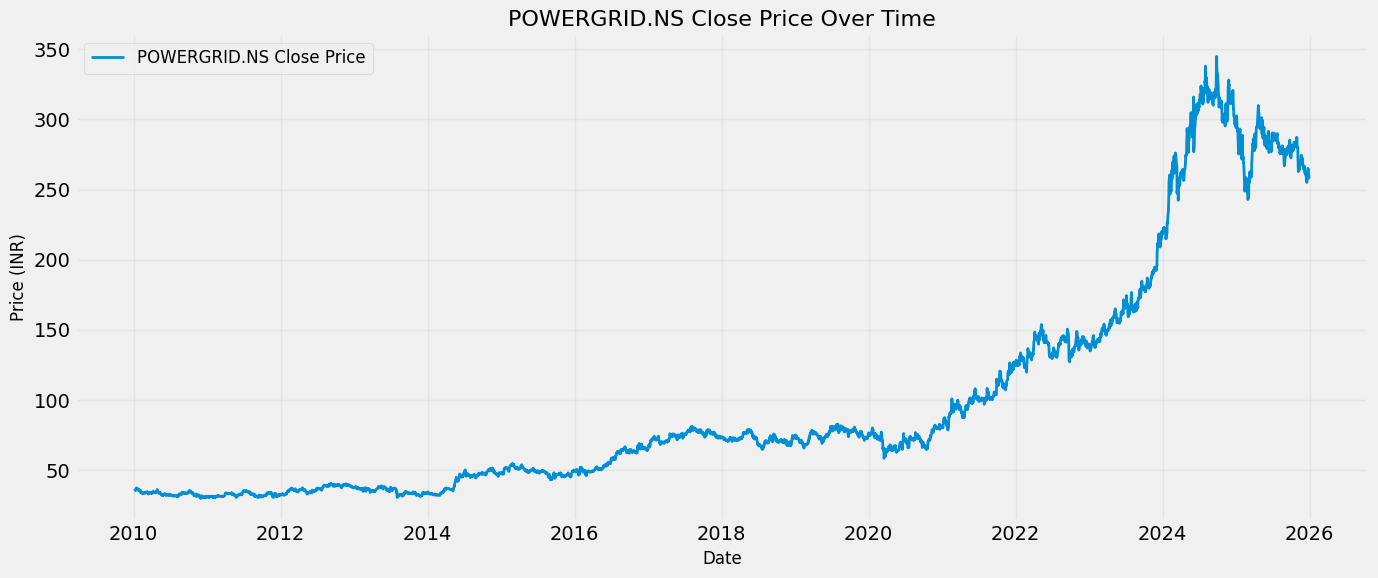

Price Statistics:
Ticker  POWERGRID.NS
count    3948.000000
mean       97.209973
std        80.364722
min        29.961134
25%        38.531700
50%        70.838264
75%       124.355492
max       344.843231


In [3]:
# Plot closing price
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['Close'], label=f'{stock} Close Price', linewidth=2)
plt.title(f'{stock} Close Price Over Time', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (INR)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Price Statistics:")
print(df['Close'].describe())

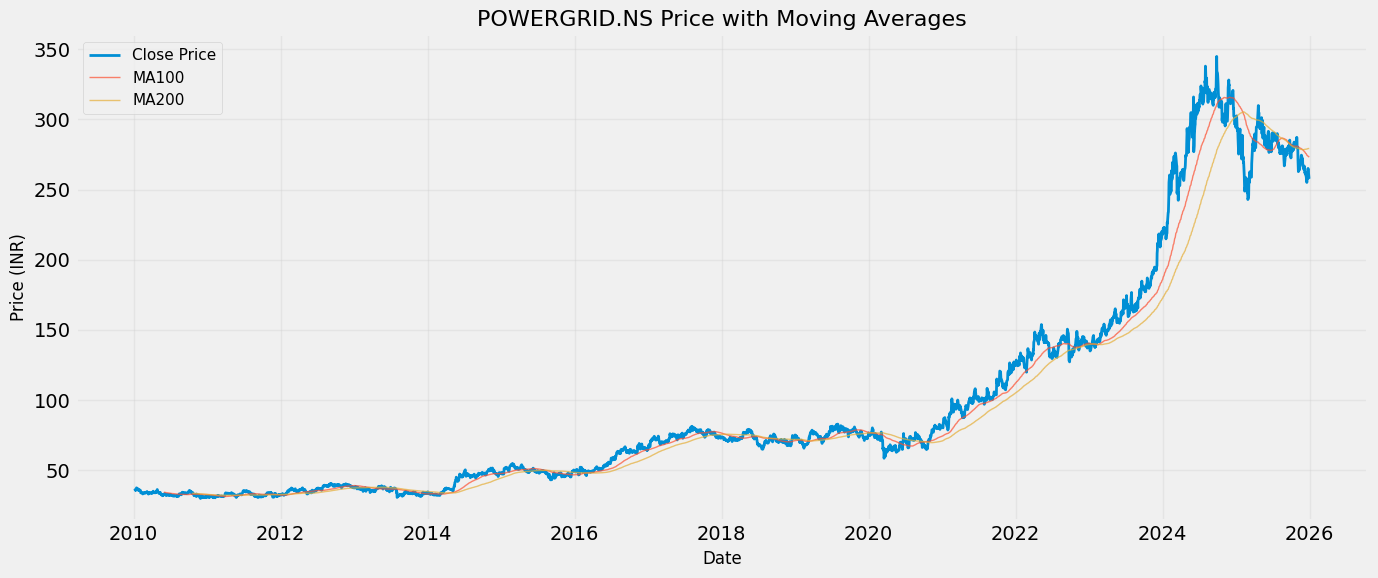

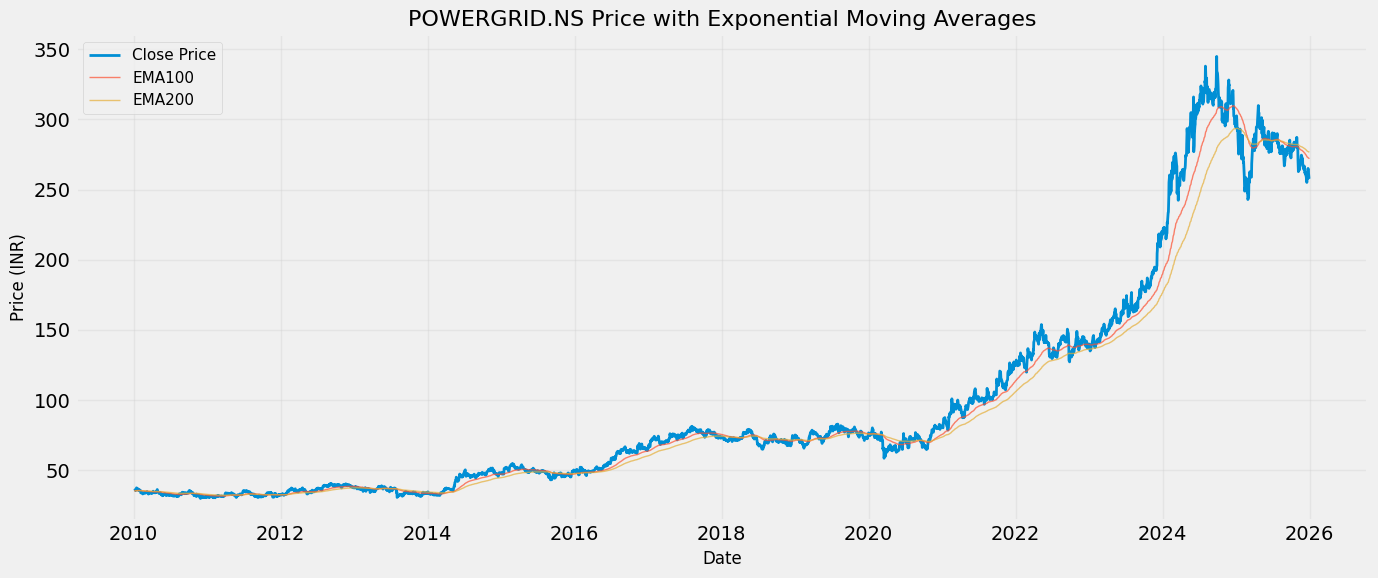

In [4]:
# Calculate moving averages
df['MA100'] = df['Close'].rolling(window=100).mean()
df['MA200'] = df['Close'].rolling(window=200).mean()
df['EMA100'] = df['Close'].ewm(span=100, adjust=False).mean()
df['EMA200'] = df['Close'].ewm(span=200, adjust=False).mean()

# Plot with moving averages
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['Close'], label='Close Price', linewidth=2)
plt.plot(df.index, df['MA100'], label='MA100', linewidth=1, alpha=0.7)
plt.plot(df.index, df['MA200'], label='MA200', linewidth=1, alpha=0.7)
plt.title(f'{stock} Price with Moving Averages', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (INR)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot with Exponential Moving Averages
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['Close'], label='Close Price', linewidth=2)
plt.plot(df.index, df['EMA100'], label='EMA100', linewidth=1, alpha=0.7)
plt.plot(df.index, df['EMA200'], label='EMA200', linewidth=1, alpha=0.7)
plt.title(f'{stock} Price with Exponential Moving Averages', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (INR)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:
# Use only Close price for prediction
data = df[['Close']].copy()

# Split data into training and testing (80-20 split)
train_size = int(len(data) * 0.80)
test_size = len(data) - train_size

print(f"Total data points: {len(data)}")
print(f"Training data points: {train_size}")
print(f"Testing data points: {test_size}")

# Separate training and testing data
train_data = data[:train_size].copy()
test_data = data[train_size:].copy()

print(f"\nTraining data shape: {train_data.shape}")
print(f"Testing data shape: {test_data.shape}")

Total data points: 3948
Training data points: 3158
Testing data points: 790

Training data shape: (3158, 1)
Testing data shape: (790, 1)


In [6]:
# Initialize scaler (FIX: Fit ONLY on training data to prevent data leakage)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_train_data = scaler.fit_transform(train_data)  # Fit on training data only

# Transform training and test data using the same scaler
scaled_test_data = scaler.transform(test_data)  # Transform using fitted scaler

print(f"✓ Scaler fitted on training data")
print(f"Scaled training data shape: {scaled_train_data.shape}")
print(f"Scaled test data shape: {scaled_test_data.shape}")
print(f"\nScaled value range: [{scaled_train_data.min():.4f}, {scaled_train_data.max():.4f}]")

✓ Scaler fitted on training data
Scaled training data shape: (3158, 1)
Scaled test data shape: (790, 1)

Scaled value range: [0.0000, 1.0000]


In [7]:
def create_sequences(data, seq_length=100):
    """Create sequences for LSTM"""
    x, y = [], []
    for i in range(len(data) - seq_length):
        x.append(data[i:i + seq_length, 0])
        y.append(data[i + seq_length, 0])
    return np.array(x), np.array(y)

# Create sequences
seq_length = 100
x_train, y_train = create_sequences(scaled_train_data, seq_length)
x_test, y_test = create_sequences(scaled_test_data, seq_length)

# Reshape for LSTM (samples, timesteps, features)
x_train = x_train.reshape((x_train.shape[0], x_train.shape[1], 1))
x_test = x_test.reshape((x_test.shape[0], x_test.shape[1], 1))

print(f"✓ Sequences created successfully")
print(f"Training sequences shape: {x_train.shape}")
print(f"Training targets shape: {y_train.shape}")
print(f"Testing sequences shape: {x_test.shape}")
print(f"Testing targets shape: {y_test.shape}")

✓ Sequences created successfully
Training sequences shape: (3058, 100, 1)
Training targets shape: (3058,)
Testing sequences shape: (690, 100, 1)
Testing targets shape: (690,)


In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Build LSTM model
model = Sequential([
    LSTM(units=50, return_sequences=True, input_shape=(seq_length, 1), activation='relu'),
    Dropout(0.2),
    LSTM(units=60, return_sequences=True, activation='relu'),
    Dropout(0.3),
    LSTM(units=80, return_sequences=True, activation='relu'),
    Dropout(0.4),
    LSTM(units=120, return_sequences=False, activation='relu'),
    Dropout(0.5),
    Dense(units=1)
])

# Compile model
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='mean_squared_error', metrics=['mae'])

print("✓ LSTM Model Architecture:")
model.summary()

# Train model
print("\nTraining LSTM model...")
history = model.fit(
    x_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

print("\n✓ Model training completed!")

✓ LSTM Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100, 50)        │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 50)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100, 60)        │        26,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100, 60)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 100, 80)        │        45,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100, 80)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 120)            │        96,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           121 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 178,761 (698.29 KB)

 Trainable params: 178,761 (698.29 KB)

 Non-trainable params: 0 (0.00 B)


Training LSTM model...
Epoch 1/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 30s 293ms/step - loss: 0.0076 - mae: 0.0597 - val_loss: 0.0277 - val_mae: 0.1097
Epoch 2/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 40s 278ms/step - loss: 0.0018 - mae: 0.0297 - val_loss: 0.0031 - val_mae: 0.0433
Epoch 3/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 20s 259ms/step - loss: 0.0014 - mae: 0.0264 - val_loss: 0.0020 - val_mae: 0.0353
Epoch 4/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 22s 290ms/step - loss: 0.0014 - mae: 0.0257 - val_loss: 0.0051 - val_mae: 0.0587
Epoch 5/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 39s 262ms/step - loss: 0.0013 - mae: 0.0259 - val_loss: 0.0104 - val_mae: 0.0851
Epoch 6/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 22s 285ms/step - loss: 0.0013 - mae: 0.0260 - val_loss: 0.0096 - val_mae: 0.0796
Epoch 7/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 25s 320ms/step - loss: 0.0010 - mae: 0.0231 - val_loss: 0.0134 - val_mae: 0.0957
Epoch 8/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 38s 500ms/step - loss: 0.0011 - mae: 0.0237 - val_loss: 0.0125 - val_mae: 0.0875
Epoch 9/50
77/77 ━━━━━━━

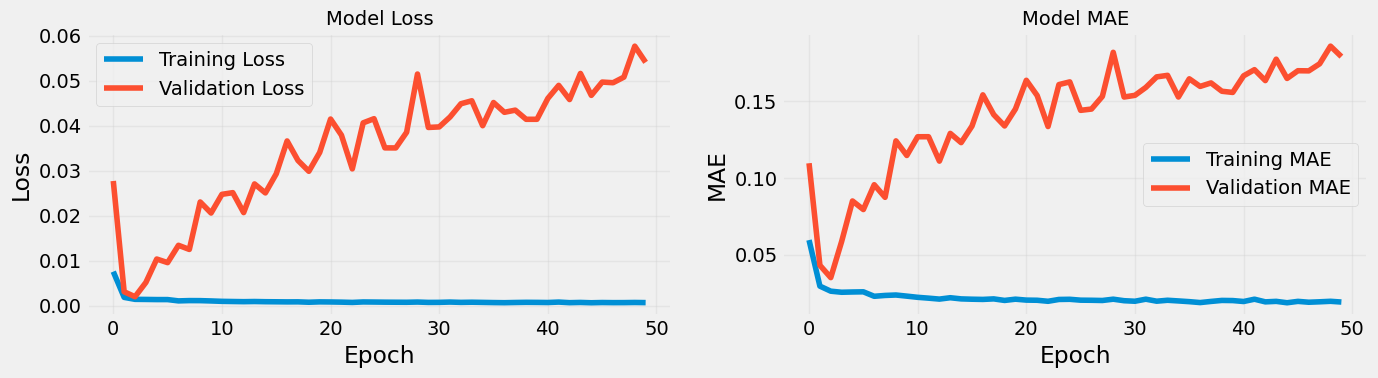

In [9]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Loss plot
axes[0].plot(history.history['loss'], label='Training Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_title('Model Loss', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MAE plot
axes[1].plot(history.history['mae'], label='Training MAE')
axes[1].plot(history.history['val_mae'], label='Validation MAE')
axes[1].set_title('Model MAE', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
# Make predictions
y_pred_lstm_scaled = model.predict(x_test)

# Inverse transform to get actual prices (FIX: Use proper inverse_transform)
y_pred_lstm = scaler.inverse_transform(y_pred_lstm_scaled)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

print(f"✓ LSTM predictions completed")
print(f"Predicted values shape: {y_pred_lstm.shape}")
print(f"Actual values shape: {y_test_actual.shape}")
print(f"\nFirst 10 predictions vs actual:")
for i in range(10):
    print(f"Predicted: {y_pred_lstm[i][0]:.2f} | Actual: {y_test_actual[i][0]:.2f}")

22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 143ms/step
✓ LSTM predictions completed
Predicted values shape: (690, 1)
Actual values shape: (690, 1)

First 10 predictions vs actual:
Predicted: 91.77 | Actual: 149.58
Predicted: 91.81 | Actual: 151.64
Predicted: 91.83 | Actual: 154.20
Predicted: 91.82 | Actual: 152.57
Predicted: 91.83 | Actual: 151.11
Predicted: 91.84 | Actual: 148.22
Predicted: 91.86 | Actual: 148.85
Predicted: 91.84 | Actual: 147.56
Predicted: 91.80 | Actual: 147.72
Predicted: 91.73 | Actual: 146.19


In [12]:
# Flatten sequences for Random Forest
x_train_rf = x_train.reshape(x_train.shape[0], -1)
x_test_rf = x_test.reshape(x_test.shape[0], -1)

# Train Random Forest
print("Training Random Forest model...")
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_model.fit(x_train_rf, y_train)

# Make predictions
y_pred_rf_scaled = rf_model.predict(x_test_rf)

# Inverse transform
y_pred_rf = scaler.inverse_transform(y_pred_rf_scaled.reshape(-1, 1))

print(f"✓ Random Forest training completed!")
print(f"\nFeature importance (top 10):")
feature_importance = rf_model.feature_importances_
top_indices = np.argsort(feature_importance)[-10:][::-1]
for idx in top_indices:
    print(f"  Feature {idx}: {feature_importance[idx]:.4f}")

Training Random Forest model...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:   15.5s


✓ Random Forest training completed!

Feature importance (top 10):
  Feature 99: 0.5650
  Feature 96: 0.1233
  Feature 97: 0.0753
  Feature 18: 0.0532
  Feature 98: 0.0457
  Feature 69: 0.0320
  Feature 17: 0.0160
  Feature 95: 0.0138
  Feature 90: 0.0107
  Feature 81: 0.0065


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   30.7s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    0.0s finished


In [13]:
# Calculate metrics for LSTM
lstm_rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_lstm))
lstm_mae = mean_absolute_error(y_test_actual, y_pred_lstm)
lstm_mape = np.mean(np.abs((y_test_actual - y_pred_lstm) / y_test_actual)) * 100

# Calculate metrics for Random Forest
rf_rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_rf))
rf_mae = mean_absolute_error(y_test_actual, y_pred_rf)
rf_mape = np.mean(np.abs((y_test_actual - y_pred_rf) / y_test_actual)) * 100

# Print comparison
print("="*60)
print("MODEL EVALUATION RESULTS")
print("="*60)
print(f"\n{'Metric':<20} {'LSTM':<20} {'Random Forest':<20}")
print("-"*60)
print(f"{'RMSE':<20} {lstm_rmse:<20.2f} {rf_rmse:<20.2f}")
print(f"{'MAE':<20} {lstm_mae:<20.2f} {rf_mae:<20.2f}")
print(f"{'MAPE (%)':<20} {lstm_mape:<20.2f} {rf_mape:<20.2f}")
print("="*60)

# Determine best model
if lstm_rmse < rf_rmse:
    print(f"\n✓ LSTM is the better model (RMSE: {lstm_rmse:.2f})")
else:
    print(f"\n✓ Random Forest is the better model (RMSE: {rf_rmse:.2f})")

MODEL EVALUATION RESULTS

Metric               LSTM                 Random Forest       
------------------------------------------------------------
RMSE                 172.78               120.38              
MAE                  162.96               107.01              
MAPE (%)             62.19                38.90               

✓ Random Forest is the better model (RMSE: 120.38)


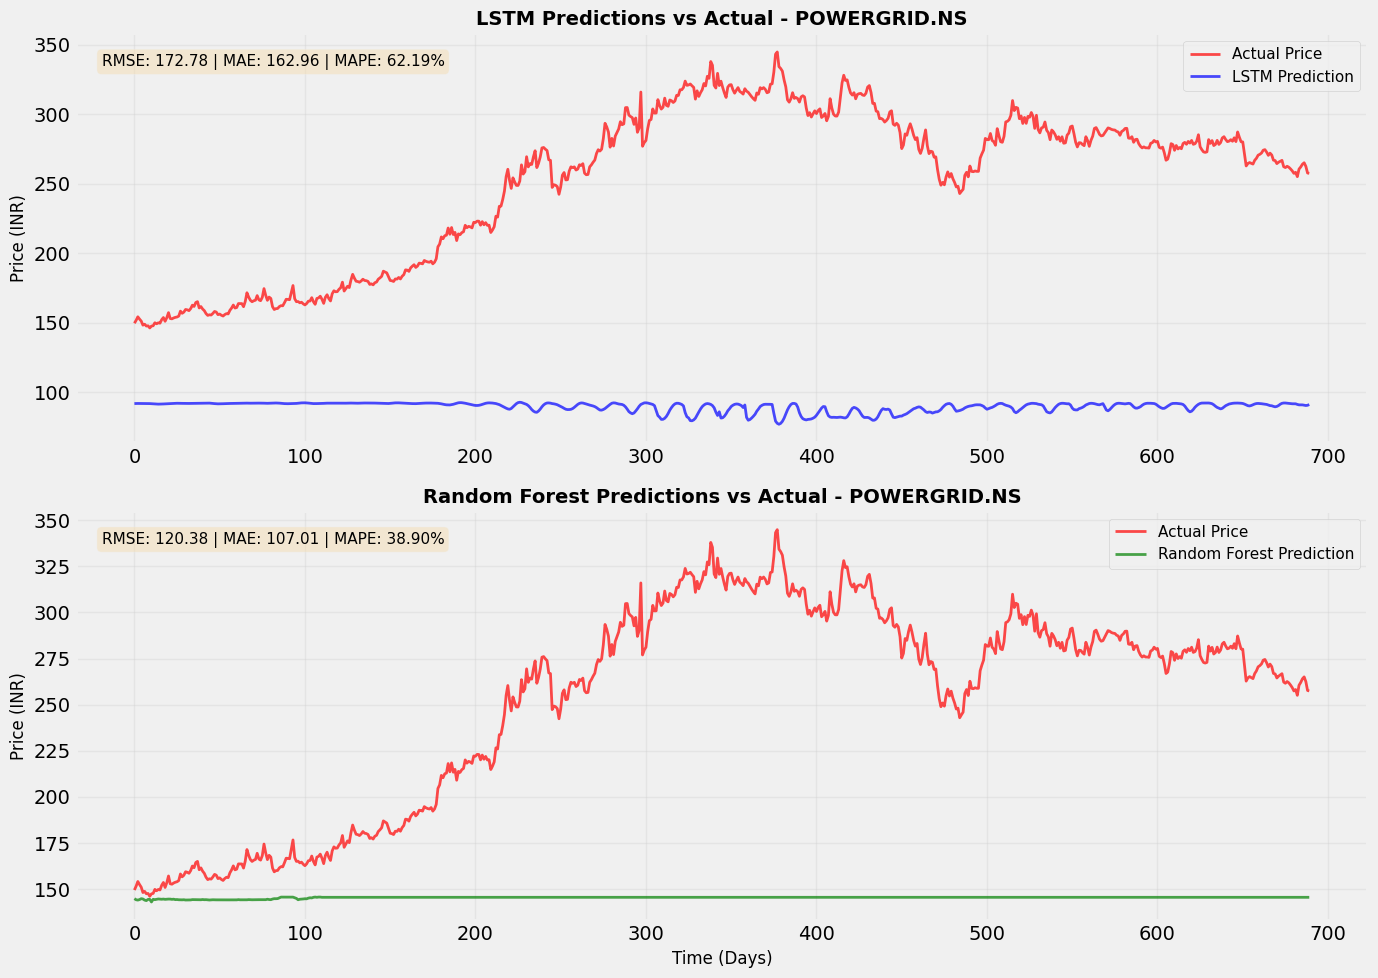

In [14]:
# Plot predictions vs actual
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# LSTM predictions
axes[0].plot(y_test_actual, label='Actual Price', color='red', linewidth=2, alpha=0.7)
axes[0].plot(y_pred_lstm, label='LSTM Prediction', color='blue', linewidth=2, alpha=0.7)
axes[0].set_title(f'LSTM Predictions vs Actual - {stock}', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Price (INR)', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].text(0.02, 0.95, f'RMSE: {lstm_rmse:.2f} | MAE: {lstm_mae:.2f} | MAPE: {lstm_mape:.2f}%',
            transform=axes[0].transAxes, fontsize=11, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Random Forest predictions
axes[1].plot(y_test_actual, label='Actual Price', color='red', linewidth=2, alpha=0.7)
axes[1].plot(y_pred_rf, label='Random Forest Prediction', color='green', linewidth=2, alpha=0.7)
axes[1].set_title(f'Random Forest Predictions vs Actual - {stock}', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Time (Days)', fontsize=12)
axes[1].set_ylabel('Price (INR)', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].text(0.02, 0.95, f'RMSE: {rf_rmse:.2f} | MAE: {rf_mae:.2f} | MAPE: {rf_mape:.2f}%',
            transform=axes[1].transAxes, fontsize=11, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

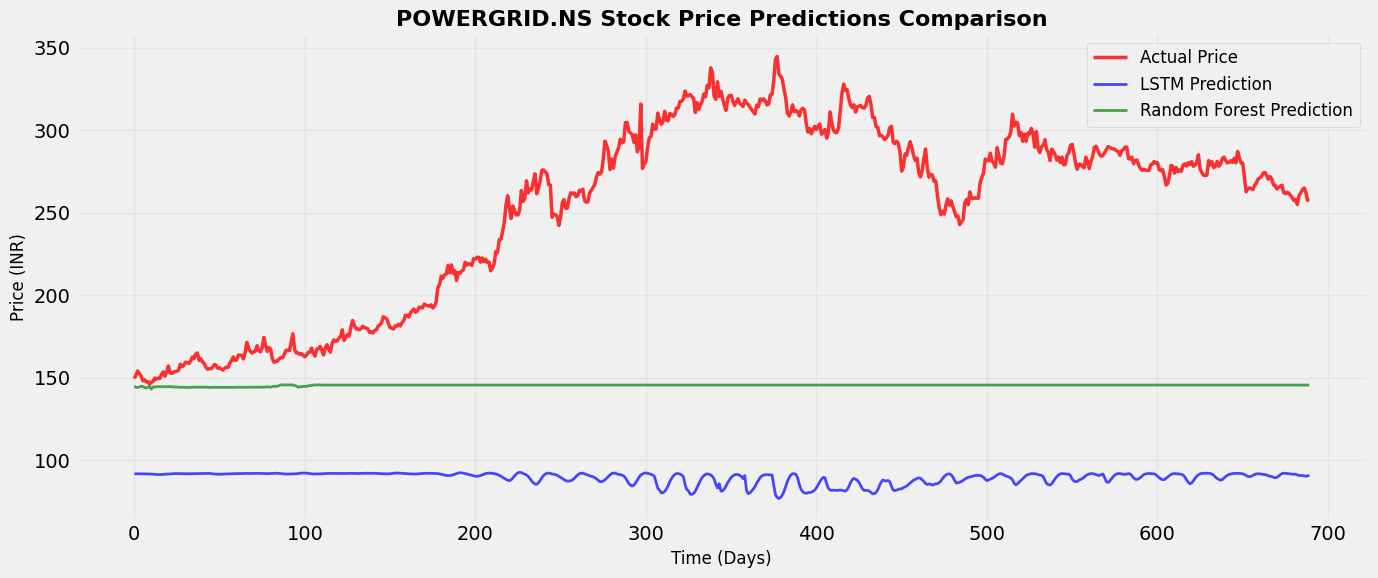

In [15]:
# Plot all predictions together
plt.figure(figsize=(14, 6))
plt.plot(y_test_actual, label='Actual Price', color='red', linewidth=2.5, alpha=0.8)
plt.plot(y_pred_lstm, label='LSTM Prediction', color='blue', linewidth=2, alpha=0.7)
plt.plot(y_pred_rf, label='Random Forest Prediction', color='green', linewidth=2, alpha=0.7)
plt.title(f'{stock} Stock Price Predictions Comparison', fontsize=16, fontweight='bold')
plt.xlabel('Time (Days)', fontsize=12)
plt.ylabel('Price (INR)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

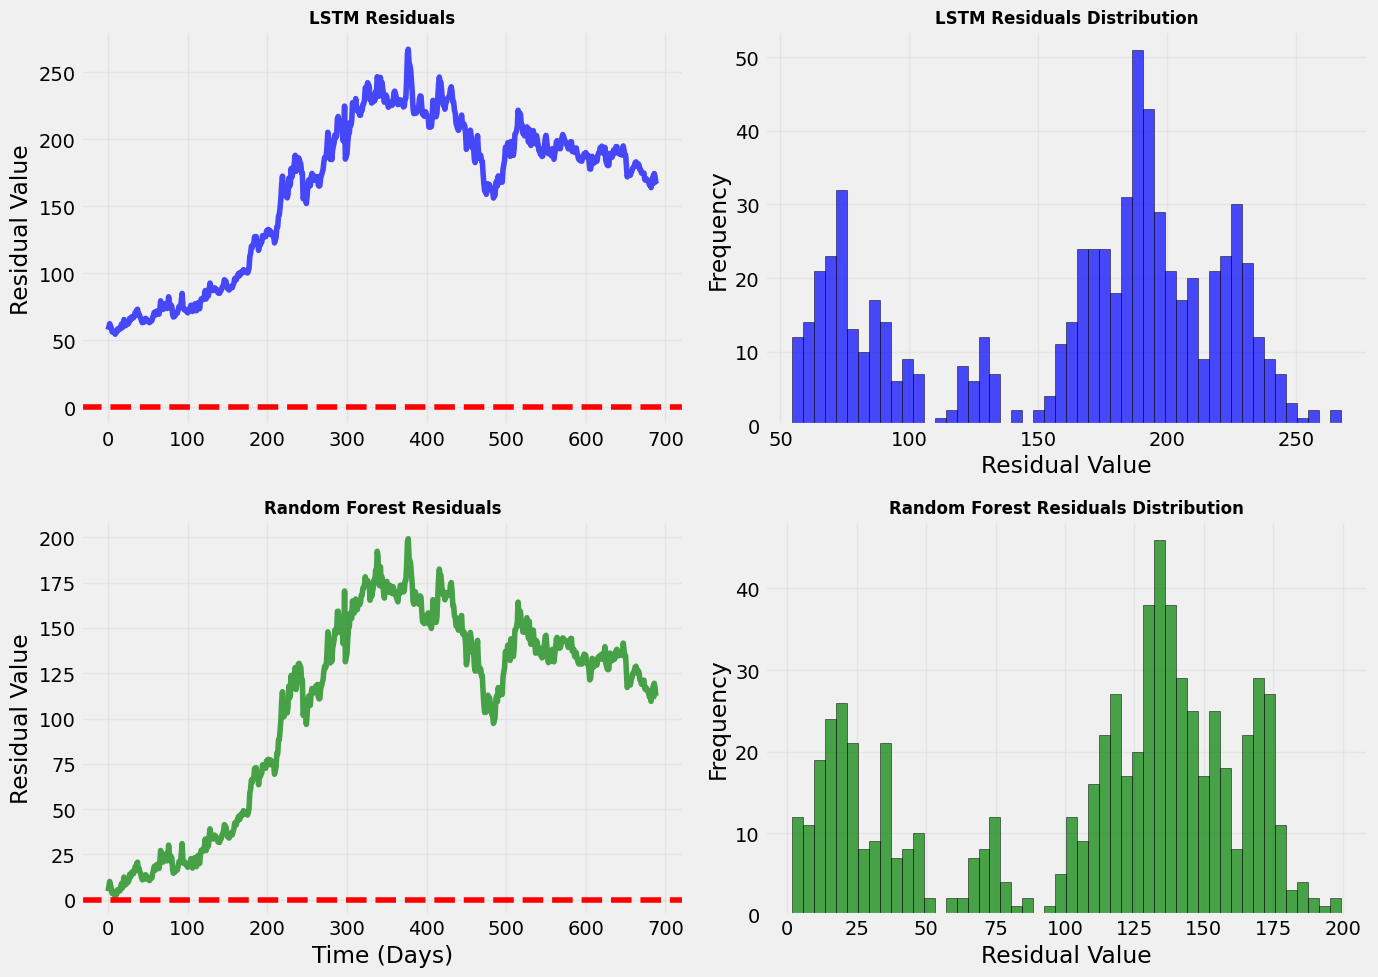

LSTM Residuals - Mean: 162.96, Std: 57.40
RF Residuals - Mean: 107.01, Std: 55.14


In [16]:
# Calculate residuals
lstm_residuals = y_test_actual - y_pred_lstm
rf_residuals = y_test_actual - y_pred_rf

# Plot residuals
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# LSTM residuals
axes[0, 0].plot(lstm_residuals, color='blue', alpha=0.7)
axes[0, 0].axhline(y=0, color='r', linestyle='--')
axes[0, 0].set_title('LSTM Residuals', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Residual Value')
axes[0, 0].grid(True, alpha=0.3)

# LSTM residuals histogram
axes[0, 1].hist(lstm_residuals, bins=50, color='blue', alpha=0.7, edgecolor='black')
axes[0, 1].set_title('LSTM Residuals Distribution', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Residual Value')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].grid(True, alpha=0.3)

# RF residuals
axes[1, 0].plot(rf_residuals, color='green', alpha=0.7)
axes[1, 0].axhline(y=0, color='r', linestyle='--')
axes[1, 0].set_title('Random Forest Residuals', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Residual Value')
axes[1, 0].set_xlabel('Time (Days)')
axes[1, 0].grid(True, alpha=0.3)

# RF residuals histogram
axes[1, 1].hist(rf_residuals, bins=50, color='green', alpha=0.7, edgecolor='black')
axes[1, 1].set_title('Random Forest Residuals Distribution', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Residual Value')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"LSTM Residuals - Mean: {lstm_residuals.mean():.2f}, Std: {lstm_residuals.std():.2f}")
print(f"RF Residuals - Mean: {rf_residuals.mean():.2f}, Std: {rf_residuals.std():.2f}")

In [17]:
# Use the last 100 days of data to predict future prices
last_data = data.tail(seq_length + 10).values
last_scaled = scaler.transform(last_data)

# Prepare last sequence for prediction
last_sequence = last_scaled[-seq_length:].reshape(1, seq_length, 1)

# Predict next 10 days
future_predictions_lstm = []
future_predictions_rf = []

current_sequence = last_sequence.copy()
current_sequence_rf = last_scaled[-seq_length:].reshape(1, -1)

for i in range(10):
    # LSTM prediction
    next_pred_lstm = model.predict(current_sequence, verbose=0)
    future_predictions_lstm.append(next_pred_lstm[0, 0])

    # Update sequence for next prediction
    current_sequence = np.append(current_sequence[:, 1:, :], next_pred_lstm.reshape(1, 1, 1), axis=1)

    # Random Forest prediction
    next_pred_rf = rf_model.predict(current_sequence_rf)[0]
    future_predictions_rf.append(next_pred_rf)

    # Update sequence for next prediction
    current_sequence_rf = np.append(current_sequence_rf[:, 1:], [[next_pred_rf]], axis=1)

# Inverse transform predictions
future_pred_lstm = scaler.inverse_transform(np.array(future_predictions_lstm).reshape(-1, 1))
future_pred_rf = scaler.inverse_transform(np.array(future_predictions_rf).reshape(-1, 1))

# Create dates for next 10 days
from datetime import timedelta
last_date = df.index[-1]
future_dates = [last_date + timedelta(days=i+1) for i in range(10)]

# Display future predictions
print("\n" + "="*70)
print("FUTURE PRICE PREDICTIONS (NEXT 10 DAYS)")
print("="*70)
print(f"{'Date':<15} {'LSTM':<20} {'Random Forest':<20}")
print("-"*70)
for i, date in enumerate(future_dates):
    print(f"{date.strftime('%Y-%m-%d'):<15} {future_pred_lstm[i][0]:<20.2f} {future_pred_rf[i][0]:<20.2f}")
print("="*70)

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_job


FUTURE PRICE PREDICTIONS (NEXT 10 DAYS)
Date            LSTM                 Random Forest       
----------------------------------------------------------------------
2025-12-31      91.78                145.63              
2026-01-01      93.17                144.00              
2026-01-02      93.08                143.56              
2026-01-03      92.51                142.61              
2026-01-04      91.33                138.73              
2026-01-05      89.61                135.35              
2026-01-06      87.54                134.29              
2026-01-07      85.20                134.30              
2026-01-08      82.53                134.30              
2026-01-09      79.42                134.30              


[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    0.0s finished


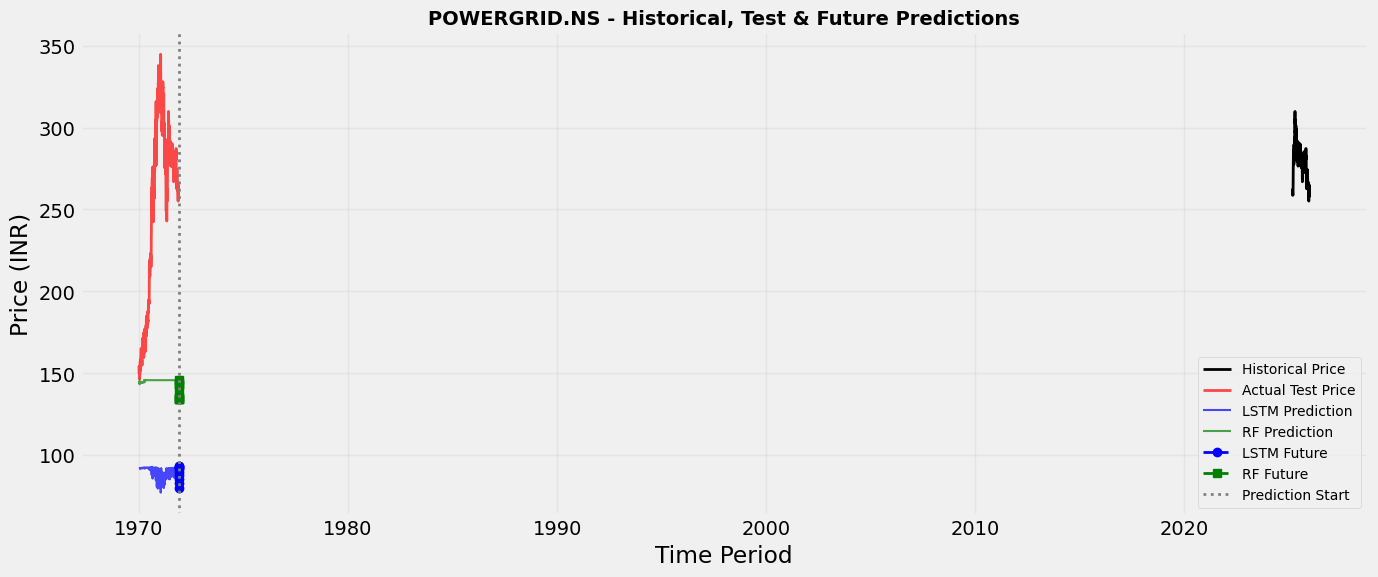

In [18]:
# Plot with future predictions
plt.figure(figsize=(14, 6))

# Historical data
plt.plot(df.index[-200:], df['Close'].tail(200), label='Historical Price', color='black', linewidth=2)

# Test predictions
plt.plot(range(len(y_test_actual)), y_test_actual, label='Actual Test Price', color='red', linewidth=2, alpha=0.7)
plt.plot(range(len(y_pred_lstm)), y_pred_lstm, label='LSTM Prediction', color='blue', linewidth=1.5, alpha=0.7)
plt.plot(range(len(y_pred_rf)), y_pred_rf, label='RF Prediction', color='green', linewidth=1.5, alpha=0.7)

# Future predictions
future_x = range(len(y_test_actual), len(y_test_actual) + 10)
plt.plot(future_x, future_pred_lstm, label='LSTM Future', color='blue', linewidth=2, linestyle='--', marker='o')
plt.plot(future_x, future_pred_rf, label='RF Future', color='green', linewidth=2, linestyle='--', marker='s')

plt.axvline(x=len(y_test_actual), color='gray', linestyle=':', linewidth=2, label='Prediction Start')
plt.title(f'{stock} - Historical, Test & Future Predictions', fontsize=14, fontweight='bold')
plt.xlabel('Time Period')
plt.ylabel('Price (INR)')
plt.legend(fontsize=10, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [21]:
print("\n" + "="*70)
print("STOCK PRICE PREDICTION - SUMMARY")
print("="*70)
print(f"\nStock: {stock}")
print(f"Data Period: {df.index[0].date()} to {df.index[-1].date()}")
print(f"Total Data Points: {len(df)}")
print(f"\nModel Performance:")
print(f"  LSTM RMSE: {lstm_rmse:.2f}")
print(f"  LSTM MAE: {lstm_mae:.2f}")
print(f"  LSTM MAPE: {lstm_mape:.2f}%")
print(f"\n  RF RMSE: {rf_rmse:.2f}")
print(f"  RF MAE: {rf_mae:.2f}")
print(f"  RF MAPE: {rf_mape:.2f}%")

if lstm_rmse < rf_rmse:
    print(f"\n✓ LSTM model is performing better!")
    print(f"  Recommendation: Use LSTM for predictions")
else:
    print(f"\n✓ Random Forest model is performing better!")
    print(f"  Recommendation: Use Random Forest for predictions")

print(f"\nCurrent Price: ₹{df['Close'].iloc[-1].item():.2f}")
print(f"Price Range (Test Period): ₹{y_test_actual.min():.2f} - ₹{y_test_actual.max():.2f}")
print(f"\nNote: Stock price prediction involves high uncertainty.")
print(f"Always consider multiple factors and expert advice before trading.")
print("="*70)


STOCK PRICE PREDICTION - SUMMARY

Stock: POWERGRID.NS
Data Period: 2010-01-04 to 2025-12-30
Total Data Points: 3948

Model Performance:
  LSTM RMSE: 172.78
  LSTM MAE: 162.96
  LSTM MAPE: 62.19%

  RF RMSE: 120.38
  RF MAE: 107.01
  RF MAPE: 38.90%

✓ Random Forest model is performing better!
  Recommendation: Use Random Forest for predictions

Current Price: ₹257.46
Price Range (Test Period): ₹146.19 - ₹344.84

Note: Stock price prediction involves high uncertainty.
Always consider multiple factors and expert advice before trading.
